In [62]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZGate
import math

In [138]:
oracle = QuantumCircuit(3)
oracle.h(2)
oracle.ccx(0, 1, 2)
oracle.h(2)

oracle.draw()

q_0: ───────■───────
            │       
q_1: ───────■───────
     ┌───┐┌─┴─┐┌───┐
q_2: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘

In [11]:
qc = QuantumCircuit()

In [ ]:
def search_algo(nb_quibits: int, nb_solution: int, oracle: QuantumCircuit):
	qc = QuantumCircuit(nb_quibits, nb_quibits)
	#qc.x(nb_quibits)
	for q in range(nb_quibits):
		qc.h(q)
	nb_iter = calcul_nb_iter(nb_quibits, nb_solution)
	for _ in range(nb_iter):
		qc.compose(oracle, inplace=True)
		for q in range(nb_quibits):
			qc.h(q)
			qc.x(q)
		
		gate = ZGate().control(nb_quibits - 1)
		qc.append(gate, range(nb_quibits))

		for q in range(nb_quibits):
			qc.x(q)
			qc.h(q)
	
	qc.measure(range(nb_quibits), range(nb_quibits))
	return qc


In [ ]:
def calcul_nb_iter(nb_quibits: int, nb_solution: int):
	
	return round((math.pi / 4) * math.sqrt(2**nb_quibits / nb_solution))

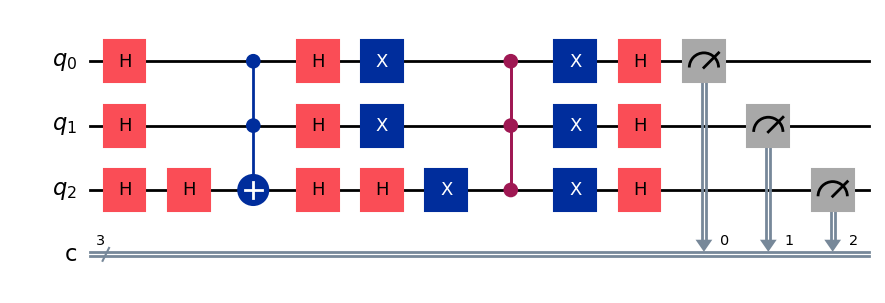

In [140]:
qc_final = search_algo(nb_quibits=3, nb_solution=1, oracle=oracle)
qc_final.draw(output='mpl')


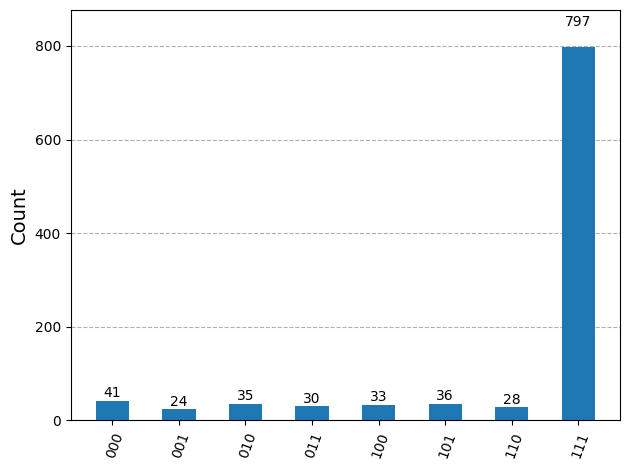

In [ ]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()
job = sim.run(qc_final, shots=1024)
result = job.result() 

counts = result.get_counts()

plot_histogram(counts)
#print(counts)


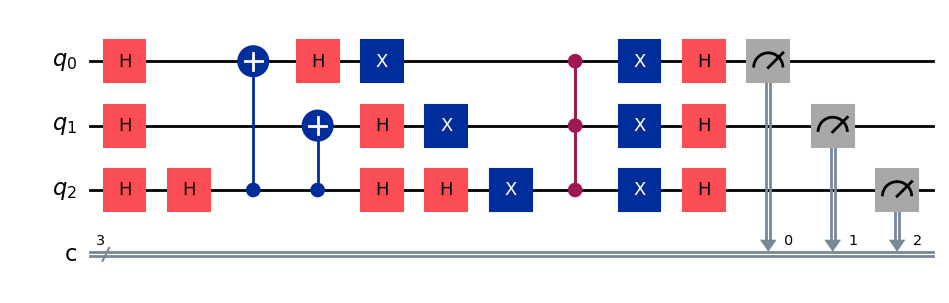

In [137]:
qc_final.draw(output='mpl')